<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part8_DevelopmentGap_Fig30-32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Dark Theme ────────────────────────────────────────────────────────────────
PAPER_BG   = '#0D1117'
PLOT_BG    = '#161B22'
GRID_C     = '#30363D'
FONT_C     = '#E6EDF3'
MUTED_C    = '#8B949E'

CITY_COLORS = {
    'Bangkok':      '#FF6B6B',
    'Singapore':    '#74B9FF',
    'Kuala Lumpur': '#4ECDC4',
    'Jakarta':      '#FFB347',
    'Manila':       '#C77DFF',
}

def apply_dark_style(ax, fig, title='', xlabel='', ylabel=''):
    fig.patch.set_facecolor(PAPER_BG)
    ax.set_facecolor(PLOT_BG)
    ax.tick_params(colors=FONT_C, labelsize=10)
    ax.xaxis.label.set_color(FONT_C)
    ax.yaxis.label.set_color(FONT_C)
    ax.title.set_color(FONT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(True, color=GRID_C, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=FONT_C, fontsize=13, fontweight='bold', pad=12, loc='left')
    if xlabel:
        ax.set_xlabel(xlabel, color=FONT_C, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=FONT_C, fontsize=10)

def millions_fmt(x, pos):
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

def style_legend(ax, fig):
    leg = ax.get_legend()
    if leg:
        leg.get_frame().set_facecolor('#1F2937')
        leg.get_frame().set_edgecolor(GRID_C)
        for text in leg.get_texts():
            text.set_color(FONT_C)
            text.set_fontsize(9)

print('Setup complete — Dark theme (Matplotlib + Seaborn) loaded')


Setup complete — Dark theme (Matplotlib + Seaborn) loaded


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('ASEAN_Urban_Growth_Final_with_Mode.csv')
df['Date']  = pd.to_datetime(df['Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# ── Mode label maps ───────────────────────────────────────────────────────────
MODE_BKK = {'BTS':'BTS Skytrain','MRT':'MRT Blue/Purple','SRT':'SRT Red Line',
             'ARL':'Airport Rail Link','YL':'MRT Yellow Line','PK':'MRT Pink Line','RL':'Regional Rail'}
MODE_SGP = {'MRT':'MRT','Public Bus':'Public Bus','LRT':'LRT'}
MODE_KL  = {
    'rail_lrt_kj':'LRT Kelana Jaya','rail_mrt_kajang':'MRT Kajang',
    'rail_lrt_ampang':'LRT Ampang','bus_rkl':'RapidKL Bus',
    'rail_mrt_pjy':'MRT Putrajaya','rail_monorail':'KL Monorail',
    'rail_komuter':'KTM Komuter','rail_komuter_utara':'KTM Utara',
    'rail_ets':'ETS Train','rail_intercity':'Intercity Rail',
    'rail_tebrau':'KTM Tebrau','bus_rkn':'RapidKN Bus','bus_rpn':'RapidPN Bus'
}
MODE_JKT = {'TRANSJAKARTA':'TransJakarta (BRT)','KRL':'KRL Commuter',
             'MRT':'MRT Jakarta','LRT':'LRT Jakarta',
             'BUS SEKOLAH':'School Bus','KCI COMMUTER BANDARA':'Airport Rail','KAPAL':'Ferry'}

print(f'Dataset: {df.shape[0]:,} rows | {df["City"].nunique()} cities')
print('Cities:', df['City'].unique().tolist())

Dataset: 2,027 rows | 5 cities
Cities: ['Bangkok', 'Jakarta', 'Kuala Lumpur', 'Singapore', 'Manila']


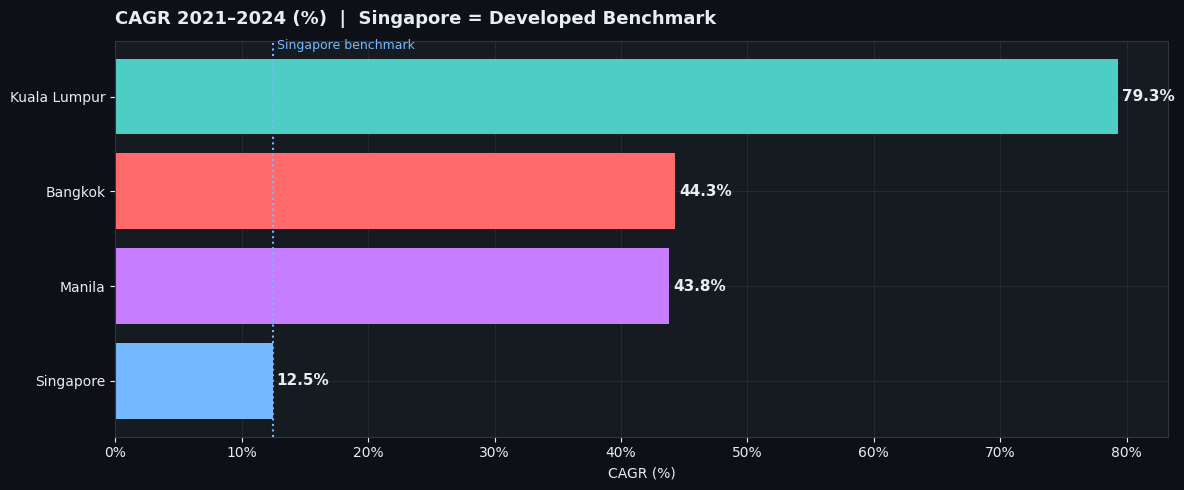

In [6]:
# ── Fig.30: CAGR Bar ────────────────────────────────────────────────────────────
yearly = df.groupby(['Year', 'City'])['Ridership'].sum().reset_index()
yearly = yearly.rename(columns={'Ridership': 'Total_Ridership'})

def calc_cagr(s, y0, y1):
    p = s.set_index('Year')['Total_Ridership']
    if y0 in p.index and y1 in p.index and p[y0]>0 and p[y1]>0:
        return ((p[y1]/p[y0])**(1/(y1-y0))-1)*100
    return float('nan')

cagr_data = []
for city in yearly['City'].unique():
    v = calc_cagr(yearly[yearly['City']==city], 2021, 2024)
    if not (v != v):  # not NaN
        cagr_data.append({'City':city,'CAGR':v})
cagr_df = pd.DataFrame(cagr_data).sort_values('CAGR')

sg_cagr = cagr_df[cagr_df['City']=='Singapore']['CAGR'].values[0]

fig, ax = plt.subplots(figsize=(12, 5))
colors = [CITY_COLORS.get(c,'#AAAAAA') for c in cagr_df['City']]
bars = ax.barh(cagr_df['City'], cagr_df['CAGR'], color=colors, edgecolor='none')
for bar, val in zip(bars, cagr_df['CAGR']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color=FONT_C, fontsize=11, fontweight='bold')
ax.axvline(sg_cagr, color=CITY_COLORS['Singapore'], linestyle=':', linewidth=1.5)
ax.text(sg_cagr + 0.3, len(cagr_df) - 0.5,
        'Singapore benchmark', color=CITY_COLORS['Singapore'], fontsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f}%'))
apply_dark_style(ax, fig,
    title='CAGR 2021–2024 (%)  |  Singapore = Developed Benchmark',
    xlabel='CAGR (%)')
fig.tight_layout()
plt.show()


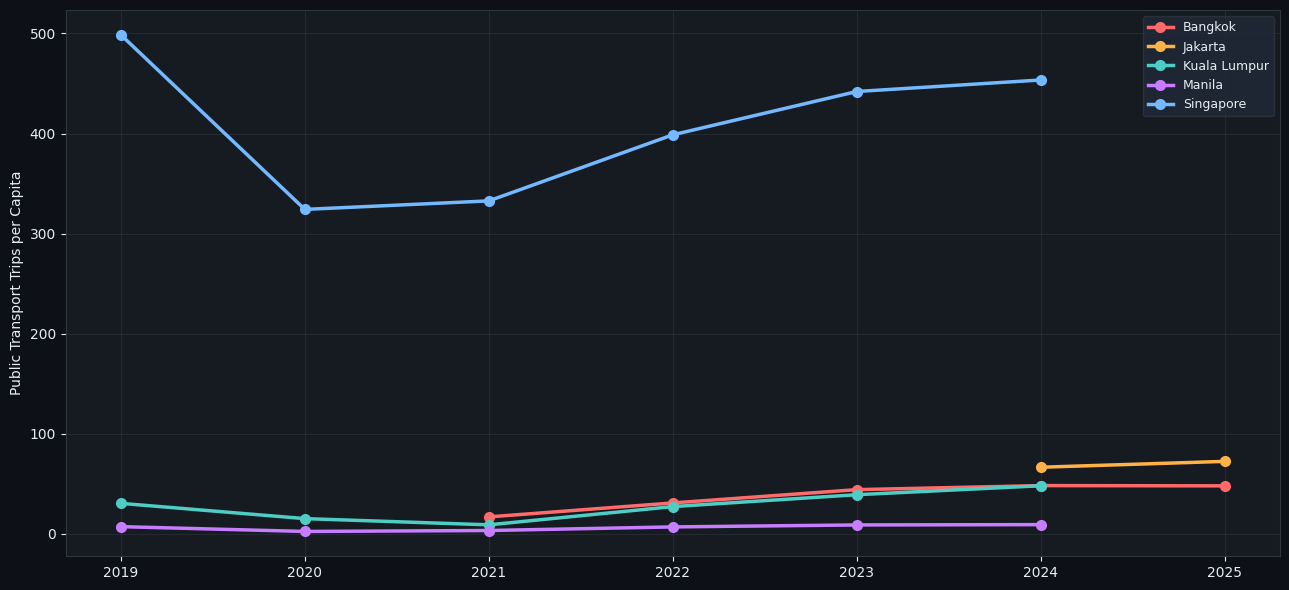

In [7]:
# ── Fig.31: Passenger per Capita Fig.25  เที่ยวโดยสารต่อคนต่อปี (Passenger per Capita) — วัดระดับการพึ่งพา ────────────────────────────────────────────────
ppc = df.groupby(['Year','City'])['Passenger_per_Capita'].sum().reset_index()
ppc = ppc[ppc['Year'].between(2019,2025)]
ppc = ppc[~((ppc['Year']==2025)&(ppc['City'].isin(['Kuala Lumpur','Manila'])))]

fig, ax = plt.subplots(figsize=(13, 6))
for city, grp in ppc.groupby('City'):
    grp = grp.sort_values('Year')
    color = CITY_COLORS.get(city, '#AAAAAA')
    ax.plot(grp['Year'], grp['Passenger_per_Capita'],
            color=color, linewidth=2.5, marker='o', ms=7, label=city)
ax.set_xticks(range(2019, 2026))
apply_dark_style(ax, fig,
    title='',
    ylabel='Public Transport Trips per Capita')
ax.legend(fontsize=9)
style_legend(ax, fig)
fig.tight_layout()
plt.show()


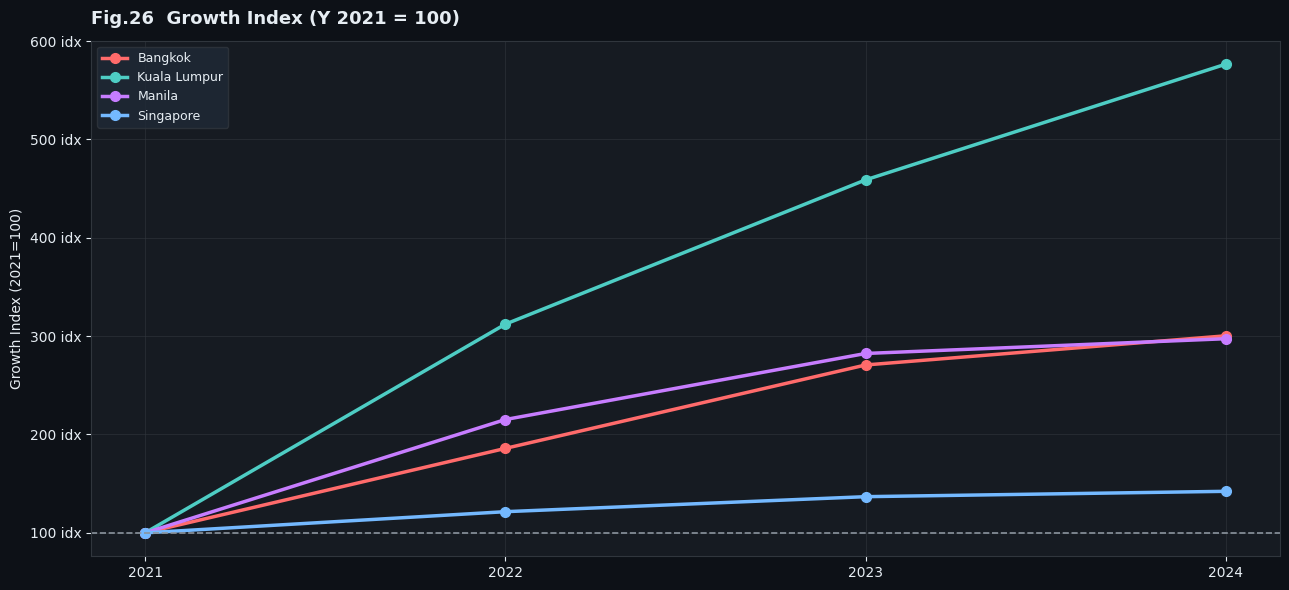

In [9]:
# ── Fig.32: Growth Index (2021 = 100) ──────────────────────────────────────────
base_yr = yearly[yearly['Year'].between(2021,2024)].copy()
idx_list=[]
for city in base_yr['City'].unique():
    sub = base_yr[base_yr['City']==city].sort_values('Year').copy()
    if 2021 in sub['Year'].values:
        base_val = sub[sub['Year']==2021]['Total_Ridership'].values[0]
        sub['Index'] = sub['Total_Ridership']/base_val*100
        idx_list.append(sub)
idx_df = pd.concat(idx_list)

fig, ax = plt.subplots(figsize=(13, 6))
for city, grp in idx_df.groupby('City'):
    grp = grp.sort_values('Year')
    color = CITY_COLORS.get(city, '#AAAAAA')
    ax.plot(grp['Year'], grp['Index'],
            color=color, linewidth=2.5, marker='o', ms=7, label=city)
ax.axhline(100, color=MUTED_C, linestyle='--', linewidth=1.2)
ax.set_xticks(sorted(idx_df['Year'].unique()))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0f} idx'))
apply_dark_style(ax, fig,
    title='Fig.26  Growth Index (Y 2021 = 100) ',
    ylabel='Growth Index (2021=100)')
ax.legend(fontsize=9)
style_legend(ax, fig)
fig.tight_layout()
plt.show()
